# Getting Started

These tutorials are meant to be followed in sequential order. Please make sure you've already gone through the [linear model example](../simple_example/run_example_adaptive.ipynb) prior to continuing.

# Key Takeaways

From this tutorial we will learn:
- how to get the posterier probability of an unknown standard deviation from noisy data
- how to plot confidence and prediction intervals

### Import all necessary modules

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.stats import uniform, norm
from smcpy import AdaptiveSampler, VectorMCMC, VectorMCMCKernel
from smcpy.utils.intervals import compute_intervals
from smcpy.utils.noise_generator import generate_noisy_data

# Example Problem: Damped Harmonic Oscillator Model

### Problem Description

This time we don't know the standard deviation, and the goal will be to fit a damped oscillator model to noisy data. The noisy data is represented:

$$y_i = 2e^{-\frac{Ct}{2}} \cos\left( \sqrt{K - \frac{C^2}{4}} \, t \right) + \epsilon_i$$

Where $y_i$ is a single observation at time $t_i$ and $\epsilon_i$ represents independent and identically distributed measurement noise. Once again we will generate synthetic data by adding a zero-mean, normally distributed noise with standard deviation $\sigma = 0.1$ to the harmonic oscillator model, defined by a damping coefficient of $C = 1.5$ and a stiffness coefficient of $K = 20.5$.

The goal will be to learn the posterior probability distribution over $A$, $B$, and standard deviation on the available data across $t_i = [0, 5]$.

### Creating the Damped Harmonic Oscillator Model

We first define our model as:

$$y_i = 2e^{-\frac{Ct}{2}} \cos\left( \sqrt{K - \frac{C^2}{4}} \, t \right)$$

To represent this we created a `DampedHarmonicOscillator` class that takes in a 2D parameter reprsenting the times (seconds) where the noisy data has been observed.

`DampedHarmonicOscillator` also has a method called `evaluate` that runs our model. `evaluate` takes in a separate 2D parameter array containing all the $C$ and $K$ coefficients.
    

In [2]:
class DampedHarmonicOscillator:
    def __init__(self, t):
        self.t = t

    def evaluate(self, params):
        C = params[:, 0, None]
        K = params[:, 1, None]
        term1 = 2 * np.exp(-C * self.t / 2)
        term2 = np.cos(np.sqrt(K - C**2 / 4) * self.t)
        return term1 * term2

### Generating and Plotting Noisy Data Using the Harmonic Oscilator Model

**The following code is not part of the haromonics oscillator class**. Here we define our functions to plot our data. We then define our time array, `t`, to have 501 time values evenly spaced out from 0 to 5 seconds. 

For general generation of noisy data and SMC setup, please reference the [Generating/Plotting Noisy Data](../simple_example/run_example_adaptive.ipynb#generating-and-plotting-noisy-data-using-the-linear-model) and the [Set Up](../simple_example/run_example_adaptive.ipynb#setting-up-and-running-the-smc-sampler) section of the linear model example for a more detailed explanation.

In [3]:
def plot_data(t, y, y_noisy):
    plt.figure()
    plt.plot(t, y, "-k", label="True")
    plt.plot(t, y_noisy, "bx", label="Data", ms=4)
    plt.xlabel("Time (s)")
    plt.ylabel("Displacement")
    plt.ylim(-1.5, 2.5)
    plt.xlim(0, 5)
    plt.savefig("data.png")


def plot_posterior_pairwise(step_list):
    sns.pairplot(pd.DataFrame(step_list[-1].param_dict))
    plt.savefig("pairplot.png")

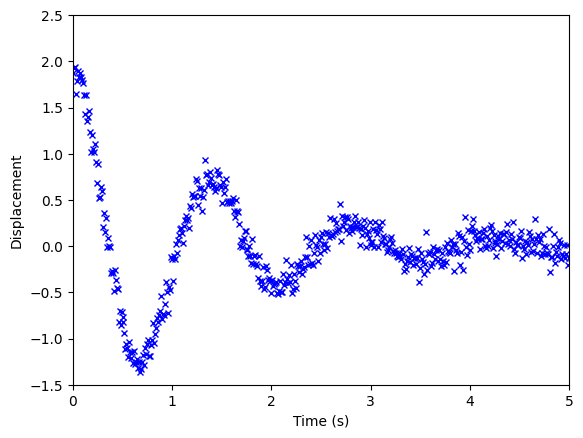

In [4]:
n = 501

t = np.linspace(0, 5, n).reshape(1, -1)
sigma = 0.1
true_params = np.array([[1.5, 20.5]])
data_seed = 1
model = DampedHarmonicOscillator(t)
interval_lvls = [0.025, 0.975]

# Generate data
y = model.evaluate(true_params)
y_noisy = generate_noisy_data(y, sigma)
np.savetxt("damped_harmonic_oscillator_data.csv", np.c_[t, y_noisy])
plot_data(t, y, y_noisy)

### Providing Priors and then Setting Up and Running the SMC Sampler

Our SMC setup is similar to the setup provided in the linear model tutorial **HOWEVER** this time we want SMC to also determine the standard deviation from our noisy data. 

We can do this by providing a variable with a `None` value and then provide it as 4th argument for `VectorMCMC`.

This is done with the lines 
```
est_std_dev = None

vmcmc = VectorMCMC(model.evaluate, y_noisy.reshape(1, -1), priors, est_std_dev)
```
as shown below.

In [5]:
priors = [uniform(0, 5), uniform(10, 30), uniform(0, 1)]

# Run SMC
est_std_dev = None

vmcmc = VectorMCMC(model.evaluate, y_noisy.reshape(1, -1), priors, est_std_dev)
kernel = VectorMCMCKernel(vmcmc, param_order=["C", "K", "std"])
smc = AdaptiveSampler(kernel)
step_list, nmll = smc.sample(num_particles=5000, num_mcmc_samples=5)

[ mutation ratio: 0.9498: : 100.00%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| phi: 1.00000/1.0 [00:21<00:00


Based from the $C$, $K$, and $\sigma$ histograms, the majoirty of the SMC samples are clustered around when $C \approx 1.4$, $K \approx 20.6$, and $\sigma \approx 0.1$. Once again these values are similarly reflecting the true values of $C = 1.5$, $K = 20.5$, and $\sigma = 0.1$ used to generate the synthetic data.

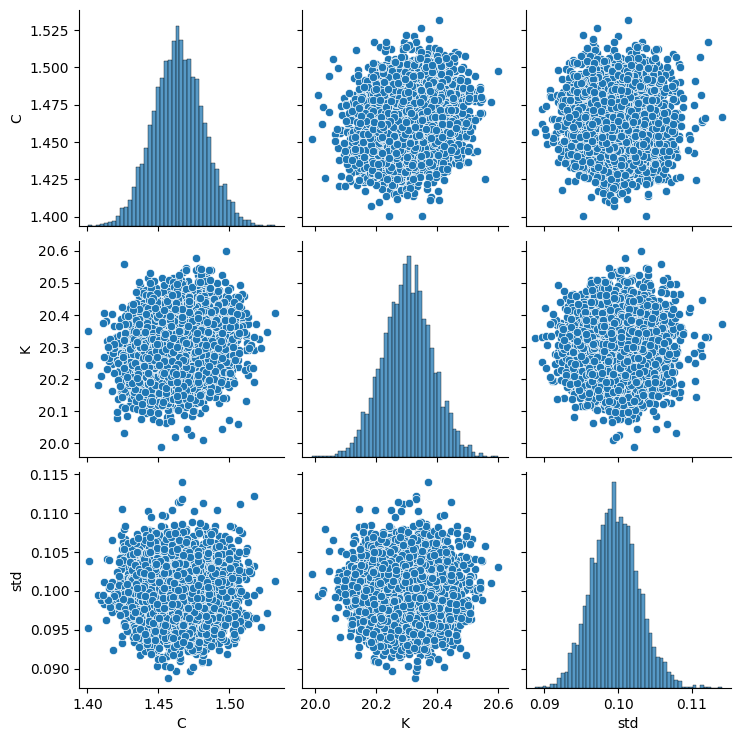

In [6]:
plot_posterior_pairwise(step_list)

### What is a Confidence and Prediction Interval?
When calculating credible and prediction intervals, we will be focusing specifically on 95% credible and 95% prediction intervals. 

**Confidence Interval**, this is an interval that characterizes all of our potential models.

**Prediction Interval**, this is an interval that characterizes where our next predicted data point will land based on our model.



A 95% confidence interval means that 95% of all potential models created with varying $C$, $K$, and $\sigma$ based on the noisy data will fall between the credible interval.

A 95% prediction interval on the other hand will try and capture 95% of future data points collected based on our model. 



### Calculating and Plotting Confidence and Prediction Intervals

Breaking Down how to Create Credible and Prediction Intervals:

We first get our model parameters, $C$, $K$, and $\sigma$ across all of our 501 samples taken. <br /> 
`samples = step_list[-1].params`

Each row represents a sample and each sample contains 3 elements. The elements represent our $C$, $K$, and $\sigma$ parameters respectively.

In [ ]:
samples = step_list[-1].params
print("Samples:", samples)


Earlier we defined our model as `model = DampedHarmonicOscillator(t)` when setting up our SMC run. We now want to update our model's time array to contain 1000 time values from 0 to 5 seconds. This ensures that the interval values are not restricted to the 501 time values from the existing data points. This also makes it so we can calculate intervals values in between these data points. <br />

In [ ]:
model.t = np.linspace(0, 5, 1000)
print("Model Time Array:", model.t)


Now we to rerun our model to get the expected harmonic oscillator values at these time values.


In [ ]:
out = model.evaluate(samples)
print("Output Data:", out)


Our prediction interval is meant to capture a percentage of our future data points. Our collected future data points is effectively the synthetic noisy data that we generate based on our model output. We will later use this noisy data to calculate our prediction intervals. <br />


In [ ]:
noisy_out = out + norm(0, samples[:, -1]).rvs((out.T.shape)).T
print("Noisy Output:", noisy_out)


Credible intervals depend on expected output values  while prediction intervals depend on synthetic noisy data. We then see these intervals created based on our model function and noisy data

We now use SMCPy's built in `compute_intervals` function to create the intervals. `compute_intervals` takes two arguments. The first is an array of samples that represents the data that we to based our intervals off of. The second is an alpha value, $\alpha$, that ranges from $0 <= \alpha <= 1$. $\alpha$ reprents the probability that our results will be outliers. In our case where we want 95% confidence intervals, this means that our $\alpha$ value will be $\alpha = 0.05$. <br />
```
cred_intervals = compute_intervals(out, 0.05)
pred_intervals = compute_intervals(noisy_out, 0.05)
```

In [ ]:
cred_intervals = compute_intervals(out, 0.05)
print("Credible Intervals", cred_intervals)

In [ ]:
pred_intervals = compute_intervals(noisy_out, 0.05)
print("Prediction Intervals:", pred_intervals)

Now that we have calculated our credible and prediction intervals its time to plot them!

In [13]:
def plot_intervals(t, cred_intervals, pred_intervals, t_data, data):
    plt.figure()
    plt.fill_between(
        t.flatten(), pred_intervals[0, :], pred_intervals[1, :], facecolor="0.8"
    )
    plt.fill_between(
        t.flatten(), cred_intervals[0, :], cred_intervals[1, :], facecolor="0.4"
    )
    plt.plot(t_data, data, "xb", label="Data", ms=2)
    plt.xlabel("Time (s)")
    plt.ylabel("Displacement")
    plt.ylim(-1.5, 2.5)
    plt.xlim(0, 5)
    plt.legend(["95% Prediction Interval", "95% Credible Interval", "Data"])
    plt.savefig("intervals.png")

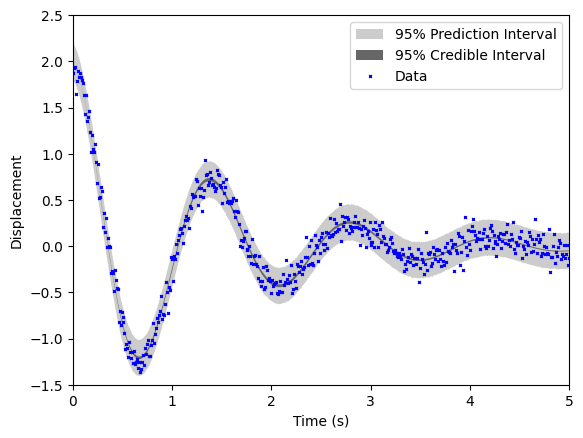

In [14]:
plot_intervals(model.t, cred_intervals, pred_intervals, t, y_noisy)

### Comparing and Interpretting Credible and Prediction Intervals



Below shows a 95% credible and 95% prediction interval of noisy data with 10, 50, 501 number of samples. This means that 95% of all potential models created with varying $C$, $K$, and $\sigma$ based on the noisy will fall between the credible internval. We notice a trend that as the amount of samples increase, the credible interval shrinks. However the prediction intervals seem to be relatively similar across all varying amounts of samples.

### 10 samples
![10_samples](../tutorial_photos/intervals10.png)
### 50 samples
![50_samples](../tutorial_photos/intervals50.png)
### 501 samples
![501_samples](../tutorial_photos/intervals501.png)